# Phase 2 — Steam Market Analytics

**Dataset:** `steam_games.csv`, 139,076 rows, snapshot date **2026-08-28** (see `outputs/feasibility_summary.md`).

This notebook builds the structured-data analytical story of the Steam marketplace, organized around four
questions rather than around individual columns:

1. How has the Steam marketplace evolved?
2. How crowded and concentrated is the marketplace (genres, developers, publishers)?
3. How does current pricing vary across the marketplace?
4. How does observed player reception/popularity vary across market segments?

**Scope boundary:** this notebook is descriptive market analytics only. It does not train predictive models,
define a success target, run NLP/topic modeling on the critic-quote file, build embeddings, or perform
clustering/recommendation — those remain out of scope per the Phase 1 feasibility call.

**Standing methodological constraints carried over from Phase 1** (see `outputs/feasibility_summary.md`):

- `price` is the **current** price, not the launch price. `estimated_owners`, `positive`/`negative` review
  counts, `recommendations`, `peak_ccu`, and `average_playtime_forever` are **current cumulative** values,
  not values known at launch — older games have simply had more time to accumulate them.
- `estimated_owners` is bucketed into only 27 ranges and ~82% of the catalog sits in the bottom one or two
  buckets; its parsed midpoint is a coarse ordinal indicator, never a precise ownership count.
- The companion `steam_games_reviews.csv` file contains critic/press pull-quotes, not player reviews, and is
  **not used in this notebook**.
- `genres`/`categories` are multi-label: a game can carry several, so prevalence percentages are not
  mutually-exclusive market shares and can sum above 100%.
- All findings here are descriptive associations conditioned on the current snapshot, never causal claims.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from audit_utils import load_games, parse_list_field, parse_estimated_owners, top_items
from market_utils import (
    add_release_year, add_review_metrics, add_ownership_midpoint, assign_price_tier,
    explode_list_counts, genre_prevalence_by_year, concentration_stats,
    cohort_genre_median, build_games_clean, PRICE_TIER_LABELS,
)

FIG_DIR = os.path.join('..', 'figures', 'phase2')
os.makedirs(FIG_DIR, exist_ok=True)

# Validated categorical palette (dataviz skill reference palette; fixed hue order, never cycled)
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    '#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948'
)
CAT_COLORS = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]
SEQ_BLUE = '#256abf'
GRAY = '#8a8a86'
TEXT_PRIMARY = '#0b0b0b'
TEXT_SECONDARY = '#52514e'

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#d8d7d2', 'axes.labelcolor': TEXT_PRIMARY,
    'text.color': TEXT_PRIMARY, 'xtick.color': TEXT_SECONDARY, 'ytick.color': TEXT_SECONDARY,
    'axes.grid': True, 'grid.color': '#ececea', 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})

def savefig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path)
    print('saved', path)

pd.set_option('display.max_columns', 50)

## Data preparation

Reuse the Phase 1 parsers (`src/audit_utils.py`) for the two known dual-serialization fields
(`genres`/`categories`, `estimated_owners`) rather than writing new parsing logic. `src/market_utils.py`
wraps these into `build_games_clean()`, producing one normalized game-level table used throughout this
notebook. The result is also saved as `data/processed/games_clean.parquet` — a small (~8 MB), deterministic,
regenerate-from-source artifact so later phases don't repeat the ~900 MB raw parse.

In [2]:
raw = load_games()
print(f"raw shape: {raw.shape}")

games = build_games_clean(raw)
games.to_parquet(os.path.join('..', 'data', 'processed', 'games_clean.parquet'), index=False)
print(f"games_clean shape: {games.shape}")
games.head(3)

raw shape: (139076, 42)


games_clean shape: (139076, 20)


,app_id,name,release_year,price,price_status,price_tier,genre_list,category_list,developers_list,publishers_list,positive,negative,total_reviews,positive_ratio,own_lo,own_hi,own_mid,peak_ccu,recommendations,average_playtime_forever
0,856050,Conjury of Nature,2018.0,4.99,paid,$0.01-4.99,"[Action, Adventure]","[Single-player, Tracked Controller Support, VR...",[SDC Ventures],[SDC Ventures],0,0,0,NaN,0,20000,10000.0,0,0.0,0
1,856060,蝶生梦影-Butterfly dream shadow,2019.0,2.99,paid,$0.01-4.99,[Casual],"[Single-player, Steam Achievements, Family Sha...",[闪金游戏],[闪金游戏],32,1,33,0.969697,0,20000,10000.0,0,0.0,0
2,856080,Mind Labyrinth VR Dreams,2018.0,19.99,paid,$10-19.99,[Adventure],"[Single-player, Steam Achievements, Tracked Co...",[Frost Earth Studio],[OXYGENE MEDIA],12,5,17,0.705882,0,20000,10000.0,0,0.0,0


### Release-year analytical window

Phase 1 found releases climbing from single/double digits per year before 2010 to tens of thousands per year
by 2024–2025, with 2026 already at 17,027 rows as of the snapshot date (2026-08-28) — i.e. **2026 is a
partial year, roughly 8 months in**. Pre-2010 years are too sparse (≤322 releases/year) to support reliable
trend or share statistics and are excluded from temporal charts. The policy used consistently below:

- **Trend charts (counts, shares, medians over time):** 2010–2025, i.e. only full calendar years with
  non-trivial volume. 2026 is shown only when explicitly labeled *partial* and never averaged into a
  "current" summary statistic alongside complete years.
- **Cohort comparisons for reception/popularity:** additionally exclude 2025 (still actively accumulating
  reviews at time of snapshot) when the comparison is meant to represent a "settled" cohort.

In [3]:
games['release_year'].describe()
counts_by_year = games['release_year'].value_counts().sort_index()
print(counts_by_year.tail(20))

release_year
2007.0       90
2008.0      158
2009.0      321
2010.0      255
2011.0      258
2012.0      322
2013.0      467
2014.0     1521
2015.0     2513
2016.0     4137
2017.0     5918
2018.0     7451
2019.0     7240
2020.0     8795
2021.0    11044
2022.0    12255
2023.0    14538
2024.0    19899
2025.0    24687
2026.0    17027
Name: count, dtype: int64


---
# Question 1 — How has the Steam marketplace evolved?

Focus: is catalog growth broad-based or concentrated, did the free-to-play share materially shift, and did
the genre mix become more or less concentrated? A single "more games were released over time" chart is not
the goal — the aim is to find structural shifts underneath the growth.

**Caveat:** this dataset is a current snapshot of what is *still listed* on Steam today. It is not a
historical census — games removed/delisted before this snapshot are invisible to us, so very old cohorts may
be undercounted relative to how large they actually were at the time.

saved ../figures/phase2/fig1_release_volume_by_year.png


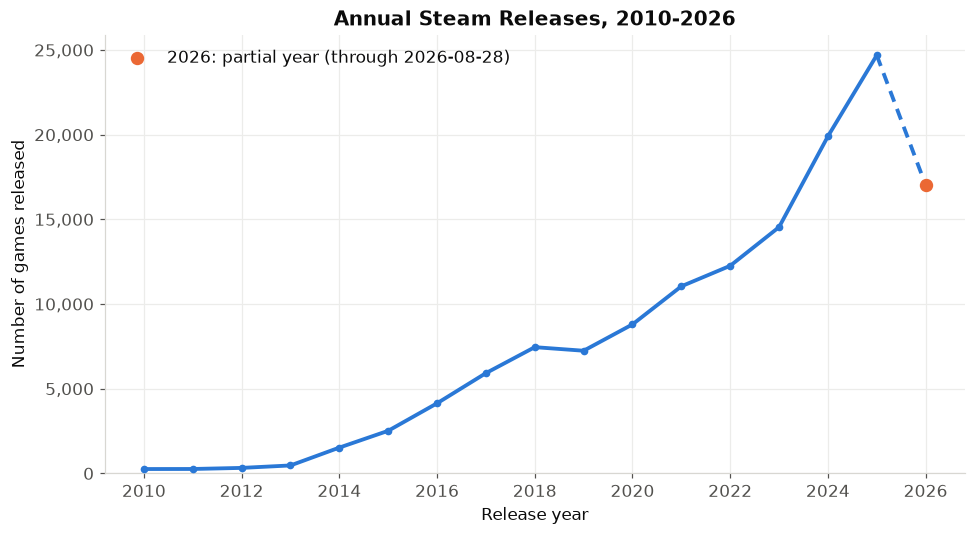

2025 (complete year): 24,687 releases
2026 (partial, ~8 months): 17,027 releases -- already 69% of 2025's full-year total
2024-2026 share of full catalog: 44.3%


In [4]:
window = games[(games['release_year'] >= 2010) & (games['release_year'] <= 2026)].copy()
counts = window['release_year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
complete = counts[counts.index <= 2025]
partial = counts[counts.index >= 2025]  # draw the 2025-2026 segment distinctly
ax.plot(complete.index, complete.values, color=BLUE, linewidth=2.5, marker='o', markersize=4, zorder=3)
ax.plot(partial.index, partial.values, color=BLUE, linewidth=2.5, linestyle=(0, (3, 2)), zorder=3)
ax.scatter([2026], [counts[2026]], color=ORANGE, s=60, zorder=4, label='2026: partial year (through 2026-08-28)')
ax.set_title('Annual Steam Releases, 2010-2026')
ax.set_xlabel('Release year')
ax.set_ylabel('Number of games released')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend(loc='upper left', frameon=False)
ax.set_ylim(bottom=0)
fig.tight_layout()
savefig(fig, 'fig1_release_volume_by_year.png')
plt.show()

print(f"2025 (complete year): {counts[2025]:,} releases")
print(f"2026 (partial, ~8 months): {counts[2026]:,} releases -- already {counts[2026]/counts[2025]:.0%} of 2025's full-year total")
print(f"2024-2026 share of full catalog: {window[window.release_year>=2024].shape[0] / len(games):.1%}")

**Interpretation.** Catalog growth is extreme and monotonic through 2025: from a few hundred releases/year
before 2013 to 24,687 in 2025. 2026 is explicitly marked as partial (through 2026-08-28) — at ~17,000
releases in ~8 months it is already tracking above a straight-line pace vs. 2025 and should **not** be read
as a year-over-year decline; it simply has not finished. This growth curve alone doesn't say *what* is
driving it, which the rest of Question 1 and Question 2 investigate.

saved ../figures/phase2/fig2_free_to_play_share_by_year.png


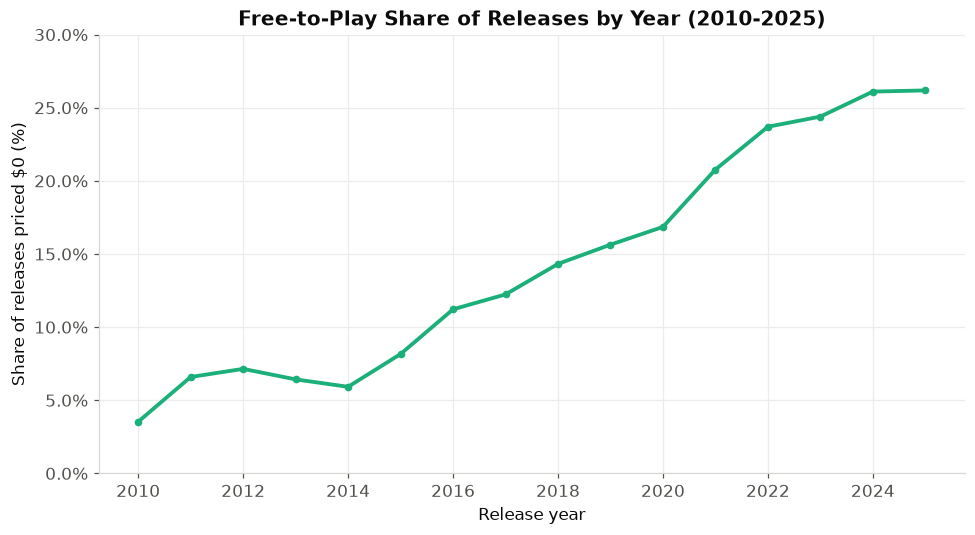

Free share 2010: 3.5%  ->  2025: 26.2%


In [5]:
window25 = games[(games['release_year'] >= 2010) & (games['release_year'] <= 2025)].copy()
free_share = window25.assign(is_free=lambda d: d['price'] == 0).groupby('release_year')['is_free'].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(free_share.index, free_share.values * 100, color=AQUA, linewidth=2.5, marker='o', markersize=4)
ax.set_title('Free-to-Play Share of Releases by Year (2010-2025)')
ax.set_xlabel('Release year')
ax.set_ylabel('Share of releases priced $0 (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, 30)
fig.tight_layout()
savefig(fig, 'fig2_free_to_play_share_by_year.png')
plt.show()

print(f"Free share 2010: {free_share.loc[2010]:.1%}  ->  2025: {free_share.loc[2025]:.1%}")

**Interpretation.** The free ($0) share of new releases rose from ~3.5% (2010) to ~26% (2024-2025) — a real
structural shift in how games are being brought to Steam, not noise. This roughly 7x proportional increase
outpaces overall catalog growth, meaning free-to-play/free-to-list titles are an increasingly important part
of *how* the platform is growing, not just a constant fraction riding the wave.

saved ../figures/phase2/fig3_genre_prevalence_trends.png


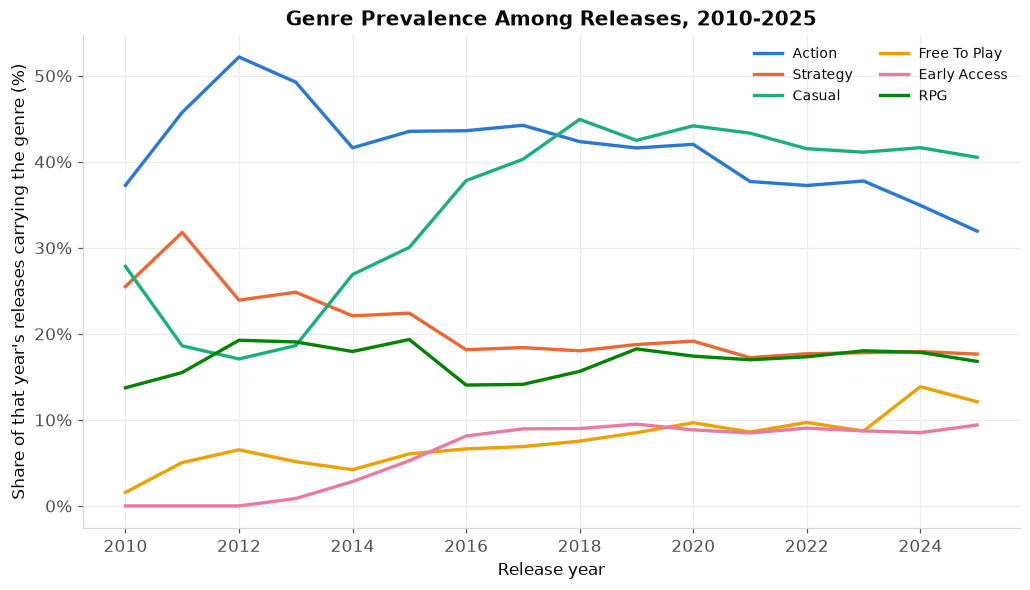

n releases: early(2014-16)=8,171  late(2023-25)=59,124  overall growth x7.2
  Indie                  early= 5,626  late=36,703  growth x  6.5
  Casual                 early= 2,728  late=24,264  growth x  8.9
  Action                 early= 3,531  late=20,325  growth x  5.8
  Adventure              early= 3,091  late=20,938  growth x  6.8
  Simulation             early= 1,466  late=12,007  growth x  8.2
  Strategy               early= 1,650  late=10,514  growth x  6.4
  RPG                    early= 1,340  late=10,319  growth x  7.7
  Free To Play           early=   490  late= 7,011  growth x 14.3
  Early Access           early=   511  late= 5,282  growth x 10.3
  Sports                 early=   364  late= 2,080  growth x  5.7
  Racing                 early=   279  late= 1,859  growth x  6.7
  Massively Multiplayer  early=   160  late= 1,081  growth x  6.8


In [6]:
games['genre_list'] = games['genre_list']  # already parsed by build_games_clean
TOP_GENRES = ['Indie', 'Casual', 'Action', 'Adventure', 'Simulation', 'Strategy', 'RPG',
              'Free To Play', 'Early Access', 'Sports', 'Racing', 'Massively Multiplayer']

trend = genre_prevalence_by_year(window25, TOP_GENRES)
piv = trend.pivot(index='year', columns='genre', values='prevalence')

show_genres = ['Action', 'Strategy', 'Casual', 'Free To Play', 'Early Access', 'RPG']
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for g, color in zip(show_genres, CAT_COLORS):
    ax.plot(piv.index, piv[g] * 100, label=g, color=color, linewidth=2.2)
ax.set_title('Genre Prevalence Among Releases, 2010-2025')
ax.set_xlabel('Release year')
ax.set_ylabel('Share of that year\'s releases carrying the genre (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(loc='upper right', frameon=False, ncol=2, fontsize=9)
fig.tight_layout()
savefig(fig, 'fig3_genre_prevalence_trends.png')
plt.show()

early = window25[window25.release_year.between(2014, 2016)]
late = window25[window25.release_year.between(2023, 2025)]
print(f"n releases: early(2014-16)={len(early):,}  late(2023-25)={len(late):,}  overall growth x{len(late)/len(early):.1f}")
for g in TOP_GENRES:
    ce = early['genre_list'].apply(lambda v: g in v).sum()
    cl = late['genre_list'].apply(lambda v: g in v).sum()
    if ce > 0:
        print(f"  {g:<22} early={ce:>6,}  late={cl:>6,}  growth x{cl/ce:>5.1f}")

**Interpretation.** Growth was **not broad-based** — genres grew at very different rates. Comparing
2014–2016 to 2023–2025 (overall catalog grew ~7.2x over that span): **Free To Play releases grew ~14x** and
**Early Access ~10x**, both far outpacing the catalog; Casual and Simulation also grew faster than average
(~9x, ~8x). Action and Strategy grew the slowest among major genres (~5.8x, ~6.4x) and their *prevalence*
(share of each year's releases) visibly declined — Action fell from carrying roughly half of releases around
2012 to about a third by 2025, and Strategy fell from the mid-20s% to the high teens. **The catalog didn't
just get bigger — its composition shifted toward free/early-access release models and away from traditional
premium Action/Strategy titles as a share of the whole**, even though absolute Action/Strategy release counts
kept growing.

---
# Question 2 — How crowded and concentrated is the Steam marketplace?

Two supply-side lenses: (a) genre/category crowding — which segments have the most releases and which are
growing fastest, and (b) developer/publisher concentration — is the catalog dominated by a few studios or
extremely fragmented? Genre percentages below are **prevalence**, not mutually-exclusive market share (a
game can carry several genres, so values can sum above 100%). Developer/publisher concentration is measured
by **catalog/release counts**, not revenue — this dataset has no sales or revenue field.

saved ../figures/phase2/fig4_genre_landscape_prevalence_and_growth.png


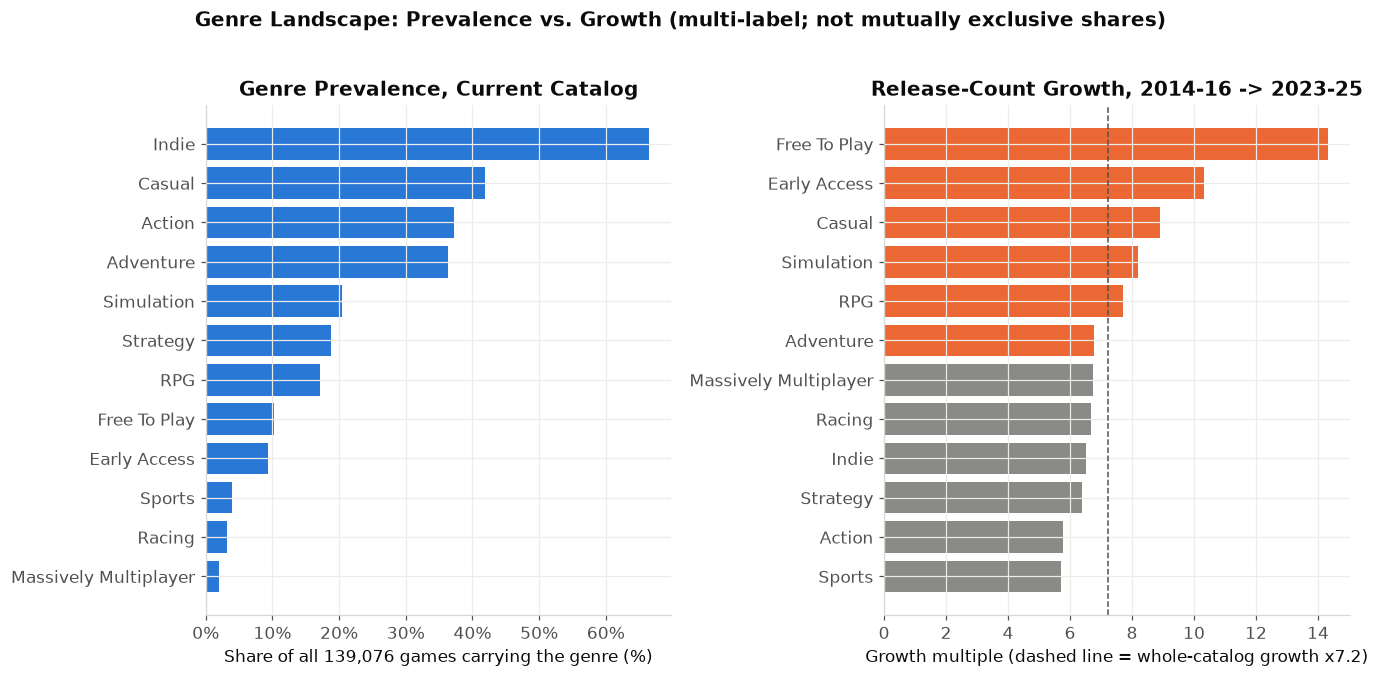

Indie                    92478
Casual                   58162
Action                   51880
Adventure                50524
Simulation               28337
Strategy                 26235
RPG                      23941
Free To Play             14254
Early Access             12900
Sports                    5435
Racing                    4504
Massively Multiplayer     2840
dtype: int64

Free To Play             14.3
Early Access             10.3
Casual                    8.9
Simulation                8.2
RPG                       7.7
Adventure                 6.8
Massively Multiplayer     6.8
Racing                    6.7
Indie                     6.5
Strategy                  6.4
Action                    5.8
Sports                    5.7
dtype: float64


In [7]:
genre_counts = explode_list_counts(games['genre_list'])
gs = pd.Series(genre_counts).sort_values(ascending=False)
top12 = gs.head(12)

growth = {}
for g in top12.index:
    ce = early['genre_list'].apply(lambda v: g in v).sum()
    cl = late['genre_list'].apply(lambda v: g in v).sum()
    growth[g] = cl / ce if ce > 0 else np.nan
growth_s = pd.Series(growth).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 6))

ax = axes[0]
order = top12.sort_values()
ax.barh(order.index, order.values / len(games) * 100, color=BLUE)
ax.set_title('Genre Prevalence, Current Catalog')
ax.set_xlabel('Share of all 139,076 games carrying the genre (%)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

ax = axes[1]
order2 = growth_s.sort_values()
colors = [ORANGE if v >= growth_s.median() else GRAY for v in order2.values]
ax.barh(order2.index, order2.values, color=colors)
ax.axvline(len(late) / len(early), color=TEXT_SECONDARY, linewidth=1, linestyle='--')
ax.set_title('Release-Count Growth, 2014-16 -> 2023-25')
ax.set_xlabel('Growth multiple (dashed line = whole-catalog growth x{:.1f})'.format(len(late) / len(early)))

fig.suptitle('Genre Landscape: Prevalence vs. Growth (multi-label; not mutually exclusive shares)', y=1.02, fontweight='bold')
fig.tight_layout()
savefig(fig, 'fig4_genre_landscape_prevalence_and_growth.png')
plt.show()

print(top12)
print()
print(growth_s.round(1))

**Interpretation.** Indie (66.5% prevalence), Casual (41.8%), Action (37.3%) and Adventure (36.3%) are the
largest genre labels in the current catalog — most games in most genres also carry the Indie tag, so "Indie"
functions more like a catalog-wide baseline than a differentiated segment. On growth, **Free To Play and
Early Access are the most "crowded" recent cohorts relative to their own history** (fastest release growth,
right panel), while Action and Strategy trail the whole-catalog growth rate — consistent with Q1's prevalence
decline for those genres.

In [8]:
def concentration_table(list_col, label):
    counts = pd.Series(explode_list_counts(games[list_col]))
    stats = concentration_stats(counts)
    print(f"--- {label} ---")
    for k, v in stats.items():
        print(f"  {k}: {v:,.4f}" if isinstance(v, float) else f"  {k}: {v:,}")
    return counts

dev_counts = concentration_table('developers_list', 'Developers')
print()
pub_counts = concentration_table('publishers_list', 'Publishers')
print()
print('Top 5 developers by catalog-entry count:')
print(dev_counts.sort_values(ascending=False).head(5))
print()
print('Top 5 publishers by catalog-entry count:')
print(pub_counts.sort_values(ascending=False).head(5))

--- Developers ---
  n_entities: 86,963
  n_game_links: 142,979
  share_single_game_entities: 0.7726
  top10_share: 0.0109
  top50_share: 0.0334
  hhi: 0.5707



--- Publishers ---
  n_entities: 73,219
  n_game_links: 135,947
  share_single_game_entities: 0.7727
  top10_share: 0.0186
  top50_share: 0.0583
  hhi: 1.4592

Top 5 developers by catalog-entry count:
EroticGamesClub             236
Choice of Games             182
Boogygames Studios          157
Laush Dmitriy Sergeevich    152
Bully Revenge Studios       150
dtype: int64

Top 5 publishers by catalog-entry count:
BFG Entertainment    555
PlayWay S.A.         285
8floor               268
EroticGamesClub      236
Kagura Games         217
dtype: int64


saved ../figures/phase2/fig5_developer_catalog_concentration.png


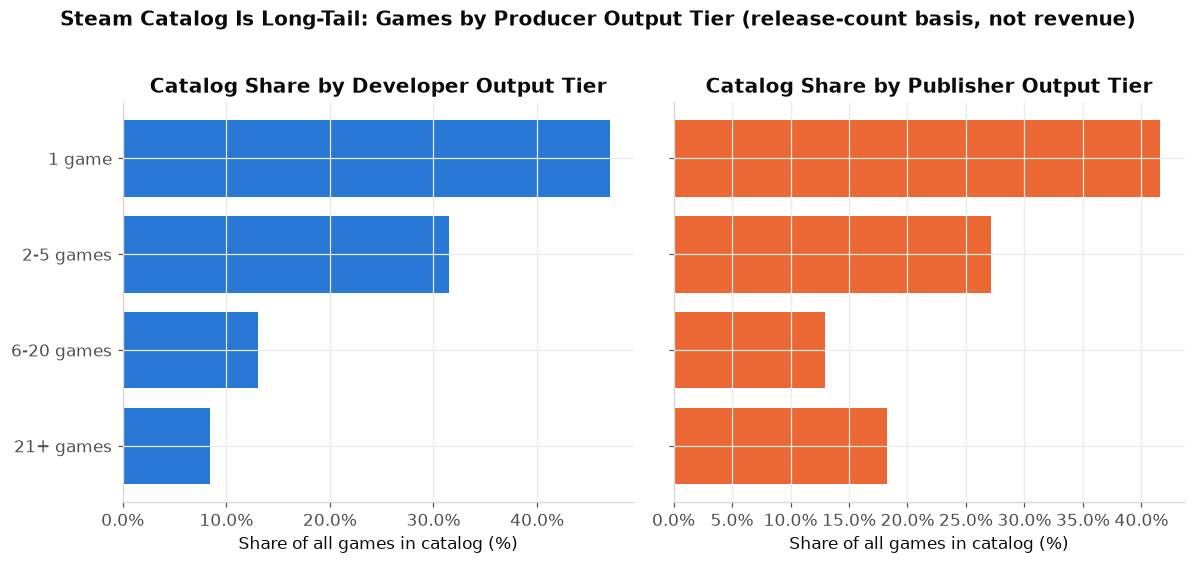

            share_of_catalog_games  share_of_entities
1 game                    0.469929           0.772627
2-5 games                 0.315263           0.200591
6-20 games                0.130159           0.023516
21+ games                 0.084649           0.003266

            share_of_catalog_games  share_of_entities
1 game                    0.416170           0.772709
2-5 games                 0.271312           0.195386
6-20 games                0.129779           0.025513
21+ games                 0.182740           0.006392


In [9]:
def tier_shares(counts):
    tiers = pd.cut(counts, bins=[0, 1, 5, 20, np.inf], labels=['1 game', '2-5 games', '6-20 games', '21+ games'])
    game_share = counts.groupby(tiers, observed=True).sum() / counts.sum()
    entity_share = counts.groupby(tiers, observed=True).size() / len(counts)
    return pd.DataFrame({'share_of_catalog_games': game_share, 'share_of_entities': entity_share})

dev_tiers = tier_shares(dev_counts)
pub_tiers = tier_shares(pub_counts)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax, tiers, label, color in zip(axes, [dev_tiers, pub_tiers], ['Developers', 'Publishers'], [BLUE, ORANGE]):
    order = tiers.index[::-1]
    ax.barh([str(i) for i in order], tiers.loc[order, 'share_of_catalog_games'] * 100, color=color)
    ax.set_title(f'Catalog Share by {label[:-1]} Output Tier')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].set_xlabel('Share of all games in catalog (%)')
axes[1].set_xlabel('Share of all games in catalog (%)')
fig.suptitle('Steam Catalog Is Long-Tail: Games by Producer Output Tier (release-count basis, not revenue)', y=1.02, fontweight='bold')
fig.tight_layout()
savefig(fig, 'fig5_developer_catalog_concentration.png')
plt.show()

print(dev_tiers)
print()
print(pub_tiers)

**Interpretation.** The catalog is extremely fragmented on a release-count basis: ~86,963 unique developers
and ~73,219 unique publishers, with **~77% of each appearing in exactly one catalog record**. The largest
single developer (EroticGamesClub, an adult-content label) and publisher (BFG Entertainment) each account for
well under 1% of the catalog; the **top-10 developers combined hold only ~1.1% of all developer-game links**,
and developer HHI is ~0.6 (out of a theoretical max of 10,000) — a near-textbook unconcentrated market by
release count. This should be read strictly as **catalog/release concentration**, not economic dominance —
plenty of small studios ship many low-visibility titles, while a single blockbuster from a major publisher
can matter far more commercially than these counts suggest. Steam's catalog supply is not dominated by a
handful of studios; it is a long tail of mostly one-off, small-output developers and publishers.

---
# Question 3 — How does pricing vary across the Steam marketplace?

**All prices below are CURRENT price as of the 2026-08-28 snapshot — not launch price**, which does not
exist in this dataset. A game's current price can differ from what it launched at due to permanent price
cuts, regional/temporal sales, or F2P conversions (Phase 1 also found `price_status` doesn't always agree
with `price == 0`: 668 "free"-status rows carry nonzero price and 3,374 "unavailable" rows do too — stale
listings). Conclusions here describe today's storefront, not pricing history.

In [10]:
print(games['price'].describe())
print()
print('Missing price:', games['price'].isna().sum(), f"({games['price'].isna().mean():.2%})")

top_priced = games.sort_values('price', ascending=False).head(10)[['name', 'price']]
print()
print(top_priced.to_string(index=False))

count    137927.000000
mean          9.030014
std         411.827572
min           0.000000
25%           0.990000
50%           4.990000
75%           9.990000
max      107500.000000
Name: price, dtype: float64

Missing price: 1149 (0.83%)

                              name     price
                        Soft Money 107500.00
                  The Honored Wife 107500.00
                     Strict Sensei  16000.00
                     MolCollabo v2   1900.00
  Congratulations On Your Purchase    999.99
The Leverage Game Business Edition    999.98
                 The Leverage Game    999.98
 Ascent Free-Roaming VR Experience    999.00
                         Zekertune    615.38
                         True Love    500.00


### Investigating the extreme prices (Phase 1 flagged up to ~$107,500)

Phase 1 found current prices reaching $107,500. Rather than deleting these rows, inspect what they actually
represent using the game's own description text and genre/category metadata.

In [11]:
extreme = raw.sort_values('price', ascending=False).head(8)[['name', 'price', 'genres', 'short_description']]
for _, row in extreme.iterrows():
    desc = str(row['short_description'])[:160]
    print(f"${row['price']:>10,.2f}  {row['name']}")
    print(f"            genres={row['genres']}")
    print(f"            \"{desc}\"")
    print()

$107,500.00  Soft Money
            genres=["Adventure", "Simulation"]
            "Eight weeks from Election Day, political consultant Wells Ashford negotiates with three women at ideological extremes: a conservative TV host, a tenants' organi"

$107,500.00  The Honored Wife
            genres=["Adventure", "Simulation"]
            "In The Honored Wife, you play as Graham Hargrove, a respected architect whose flawless life begins to crack. After twenty years of marriage, three encounters op"

$ 16,000.00  Strict Sensei
            genres=["Indie", "Simulation"]
            "Experience a day of being punished by Shizuka, your 199-cm-tall, no-nonsense, super-strict sensei."

$  1,900.00  MolCollabo v2
            genres=["Indie"]
            "MolCollabo is software that enables the 3D display of biomolecules on a HMD, allowing for a VR experience. By connecting VR spaces through network communication"

$    999.99  Congratulations On Your Purchase
            genres=["Adventure", "Simu

**Finding.** The extreme-price tail is a mix of two real, explainable categories — not bundles and not
data errors:

1. **Intentional novelty/shock pricing**: e.g. *Soft Money* and *The Honored Wife* at $107,500 each, and
   *Congratulations On Your Purchase* at $999.99, whose own description says *"The most expensive game on
   Steam... The price is not a mistake. It is the point."* — these are deliberate gimmick listings, not
   errors.
2. **Professional creative/productivity software sold through Steam's game storefront**: e.g. *Houdini Indie*
   ($299), *VEGAS Edit 20* ($249), *Aartform Curvy 3D 4.0* ($299.99), *3DF Zephyr Lite* ($249) — these carry
   genre tags like "Animation & Modeling" / "Video Production" / "Design & Illustration" and are priced like
   professional tools, not consumer games.

Both categories are legitimate current listings, so the rows are kept in the dataset, but they are excluded
from the main distribution chart below (which uses a robust ≤P99 range) so a handful of outliers don't
compress the readable range for the other 99% of the catalog.

Paid-game price percentiles: P50=5.99  P90=19.99  P99=51.14  P99.9=199.99  max=107,500.00
Games priced > P99 ($51.14): 1,102 of 110,186 paid games (1.00%)
saved ../figures/phase2/fig6_price_distribution_paid_games.png


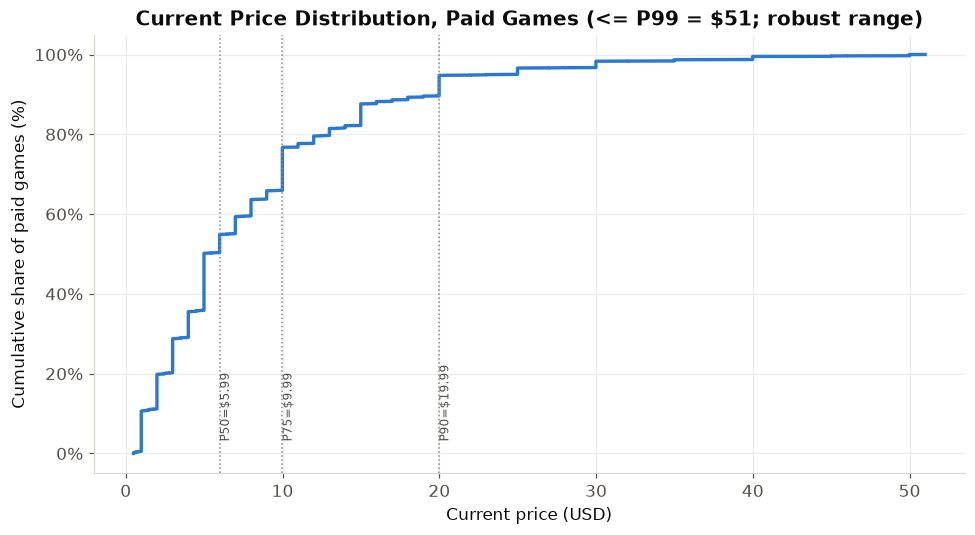

In [12]:
paid = games[games['price'] > 0].copy()
p99 = paid['price'].quantile(0.99)
print(f"Paid-game price percentiles: P50={paid['price'].median():.2f}  P90={paid['price'].quantile(0.9):.2f}  "
      f"P99={p99:.2f}  P99.9={paid['price'].quantile(0.999):.2f}  max={paid['price'].max():,.2f}")
print(f"Games priced > P99 (${p99:.2f}): {(paid['price'] > p99).sum():,} of {len(paid):,} paid games ({(paid['price'] > p99).mean():.2%})")

within = paid[paid['price'] <= p99]['price'].sort_values()
ecdf_y = np.arange(1, len(within) + 1) / len(within)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(within.values, ecdf_y * 100, color=BLUE, linewidth=2.2)
for q, style in [(0.5, ':'), (0.75, ':'), (0.9, ':')]:
    val = paid['price'].quantile(q)
    ax.axvline(val, color=GRAY, linewidth=1, linestyle=style)
    ax.text(val, 2, f' P{int(q*100)}=${val:.2f}', fontsize=8, color=TEXT_SECONDARY, rotation=90, va='bottom')
ax.set_title(f'Current Price Distribution, Paid Games (<= P99 = \${p99:.0f}; robust range)')
ax.set_xlabel('Current price (USD)')
ax.set_ylabel('Cumulative share of paid games (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
fig.tight_layout()
savefig(fig, 'fig6_price_distribution_paid_games.png')
plt.show()

**Interpretation.** Among paid games, the median current price is **$5.99** and 90% of paid games are priced
at or below **$19.99** — Steam's catalog is overwhelmingly low-priced. The distribution jumps sharply at
recognizable Steam price points ($0.99, $4.99, $9.99, $14.99, $19.99), confirming these aren't smooth
continuous prices but deliberate storefront price-point choices. The tier boundaries used below ($5 / $10 /
$20 / $40) were chosen to land on these natural breaks and align with the empirical P75/P90 percentiles.

saved ../figures/phase2/fig7_price_by_genre.png


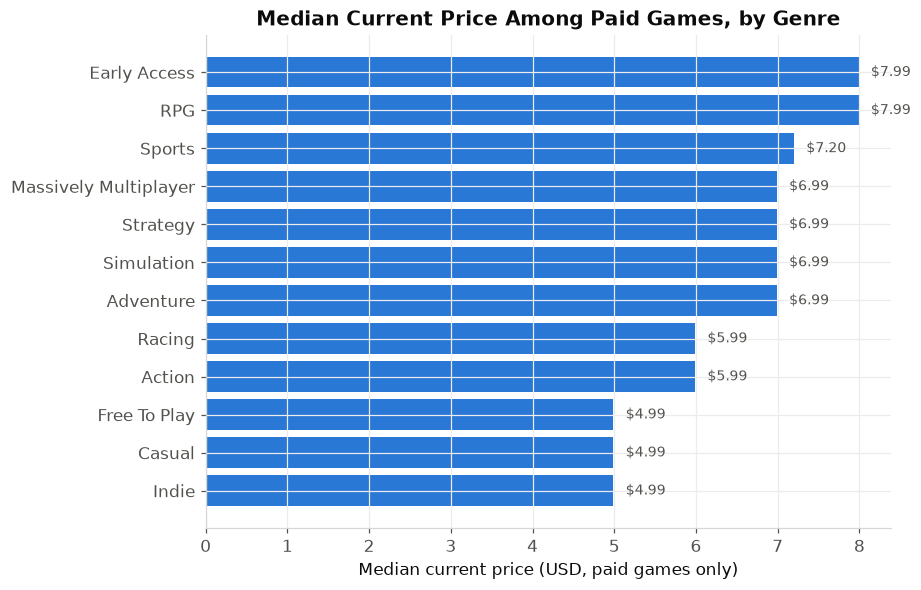

In [13]:
from market_utils import PAID_TIER_LABELS
med_price_by_genre = {}
for g in TOP_GENRES:
    mask = paid['genre_list'].apply(lambda v: g in v)
    med_price_by_genre[g] = paid.loc[mask, 'price'].median()
mp = pd.Series(med_price_by_genre).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.barh(mp.index, mp.values, color=BLUE)
for i, v in enumerate(mp.values):
    ax.text(v + 0.15, i, f'${v:.2f}', va='center', fontsize=9, color=TEXT_SECONDARY)
ax.set_title('Median Current Price Among Paid Games, by Genre')
ax.set_xlabel('Median current price (USD, paid games only)')
fig.tight_layout()
savefig(fig, 'fig7_price_by_genre.png')
plt.show()

**Interpretation.** Median paid price is fairly compressed across genres (roughly $5–$8), with RPG and
Adventure/Simulation/Strategy at the higher end (~$7-8) and Casual/Indie/Racing at the lower end (~$5-6) —
genre alone is not a strong pricing lever on Steam; most of the catalog clusters near the low-price indie
range regardless of genre.

saved ../figures/phase2/fig8_price_by_release_cohort.png


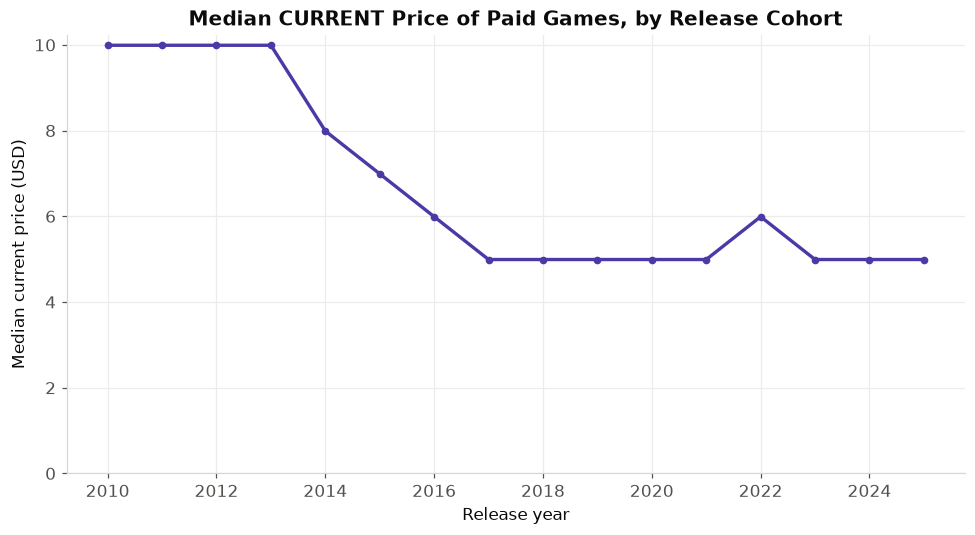

release_year
2010.0    9.99
2011.0    9.99
2012.0    9.99
2013.0    9.99
2014.0    7.99
2015.0    6.99
2016.0    5.99
2017.0    4.99
2018.0    4.99
2019.0    4.99
2020.0    4.99
2021.0    4.99
2022.0    5.99
2023.0    4.99
2024.0    4.99
2025.0    4.99
Name: price, dtype: float64


In [14]:
med_price_by_year = paid[(paid.release_year >= 2010) & (paid.release_year <= 2025)].groupby('release_year')['price'].median()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(med_price_by_year.index, med_price_by_year.values, color=VIOLET, linewidth=2.2, marker='o', markersize=4)
ax.set_title('Median CURRENT Price of Paid Games, by Release Cohort')
ax.set_xlabel('Release year')
ax.set_ylabel('Median current price (USD)')
ax.set_ylim(bottom=0)
fig.tight_layout()
savefig(fig, 'fig8_price_by_release_cohort.png')
plt.show()
print(med_price_by_year)

**Interpretation.** Older release cohorts (2010–2013) show a higher *current* median price (~$9.99) than
recent cohorts (~$4.99 from 2017 onward). **This must not be read as "games launched more expensively in
2010"** — it's the current price of games released in each year, and older paid titles are more likely to
have received permanent price cuts, bundling, or reissue pricing over their much longer time on the
storefront. It's equally consistent with newer cohorts (2017+) being disproportionately budget/indie titles
from the start, given Q1/Q2's finding that Casual/Indie prevalence rose over the same period. Both a pricing
effect and a compositional effect could produce this pattern; the data can't separate them without launch
price history, which does not exist in this dataset.

---
# Question 4 — How does observed player reception/popularity vary across market segments?

### Choosing reliable outcome metrics

Phase 1 flagged that several candidate outcomes are weak or unreliable: `average_playtime_forever` is 91.4%
zero, `recommendations` is 62% zero (among non-missing) plus 21.9% missing outright, and `peak_ccu` is 85.8%
zero. `estimated_owners` is a 27-bucket coarse ordinal. Rather than forcing all six into the analysis, this
notebook uses two metrics that are well-populated and directly interpretable:

- **`total_reviews`** (`positive + negative`) as a volume/visibility proxy — only 40.3% zero, much better
  populated than the alternatives.
- **`positive_ratio`** (`positive / total_reviews`) as a reception/quality proxy, **restricted to games with
  a minimum review count** (chosen below) since a 100%-positive game with 1 review is not comparable to a
  95%-positive game with 10,000 reviews.

In [15]:
tr = games['total_reviews']
print('Share of catalog with zero reviews:', f"{(tr == 0).mean():.1%}")
for t in [1, 5, 10, 20, 50, 100]:
    print(f'  >= {t:>3} reviews: {(tr >= t).mean():.1%} of catalog')

# stability of positive_ratio as the minimum review count rises
print()
for t in [1, 5, 10, 20, 50]:
    sub = games[games['total_reviews'] >= t]
    print(f'min_reviews={t:>3}: n={len(sub):>7,} ({len(sub)/len(games):.1%} of catalog)  '
          f'mean_ratio={sub["positive_ratio"].mean():.3f}  std={sub["positive_ratio"].std():.3f}')

Share of catalog with zero reviews: 40.3%
  >=   1 reviews: 59.7% of catalog
  >=   5 reviews: 48.3% of catalog
  >=  10 reviews: 40.8% of catalog
  >=  20 reviews: 32.1% of catalog
  >=  50 reviews: 22.1% of catalog
  >= 100 reviews: 16.4% of catalog

min_reviews=  1: n= 83,059 (59.7% of catalog)  mean_ratio=0.758  std=0.239
min_reviews=  5: n= 67,241 (48.3% of catalog)  mean_ratio=0.767  std=0.193
min_reviews= 10: n= 56,757 (40.8% of catalog)  mean_ratio=0.772  std=0.179
min_reviews= 20: n= 44,651 (32.1% of catalog)  mean_ratio=0.776  std=0.168
min_reviews= 50: n= 30,687 (22.1% of catalog)  mean_ratio=0.785  std=0.155


**Threshold choice.** At `total_reviews == 1`, a game's positive ratio can only be exactly 0% or 100% — pure
noise (std = 0.239). The standard deviation drops steadily as the minimum rises and has mostly leveled off by
**10 reviews** (std 0.179, down from 0.239 at the 1-review floor) while still retaining 40.8% of the catalog.
This notebook uses **`total_reviews >= 10`** as the minimum for all positive-ratio comparisons below. This
threshold is used only to stabilize a descriptive statistic — it is not proposed as a success-label cutoff.

saved ../figures/phase2/fig9_review_volume_long_tail.png


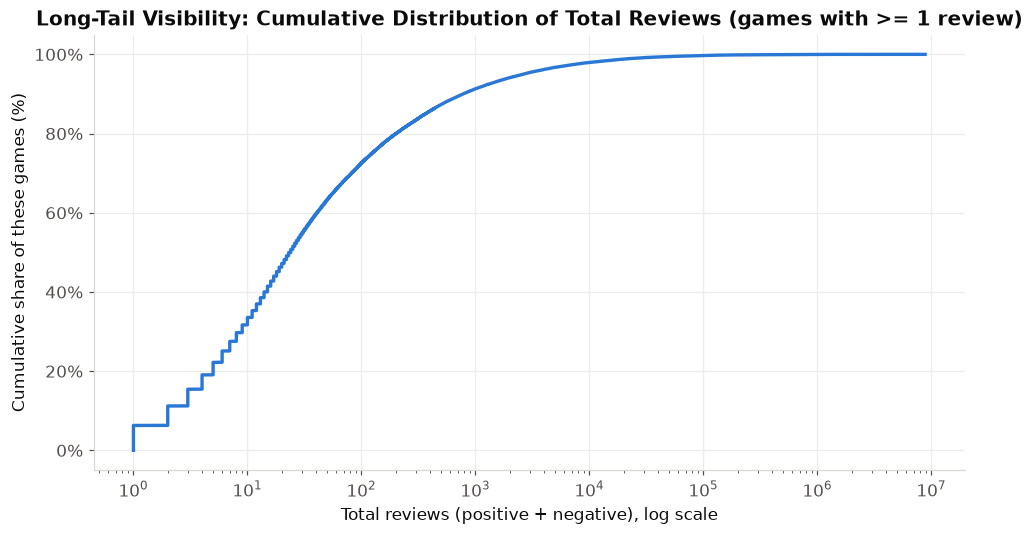

Median total_reviews among games with >=1 review: 24
Share of ALL games (including zero-review) with < 10 total reviews: 59.2%


In [16]:
tr_nonzero = tr[tr > 0]
ecdf_x = np.sort(tr_nonzero.values)
ecdf_y = np.arange(1, len(ecdf_x) + 1) / len(ecdf_x)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ecdf_x, ecdf_y * 100, color=BLUE, linewidth=2.2)
ax.set_xscale('log')
ax.set_title('Long-Tail Visibility: Cumulative Distribution of Total Reviews (games with >= 1 review)')
ax.set_xlabel('Total reviews (positive + negative), log scale')
ax.set_ylabel('Cumulative share of these games (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
fig.tight_layout()
savefig(fig, 'fig9_review_volume_long_tail.png')
plt.show()

print(f"Median total_reviews among games with >=1 review: {tr_nonzero.median():.0f}")
print(f"Share of ALL games (including zero-review) with < 10 total reviews: {(tr < 10).mean():.1%}")

**Interpretation.** Player attention on Steam is extremely long-tailed: 40.3% of the entire catalog has zero
recorded reviews, and **59.2% of all games have fewer than 10 total reviews** — i.e. below this notebook's
own stability threshold for even describing a reception ratio. This is consistent with, and reinforces,
Phase 1's finding that `estimated_owners` is bottom-heavy (~82% in the lowest one or two buckets): most Steam
games, across the whole catalog's history, receive very little observable player attention.

saved ../figures/phase2/fig10_genre_reception_alltime_vs_recent_cohort.png


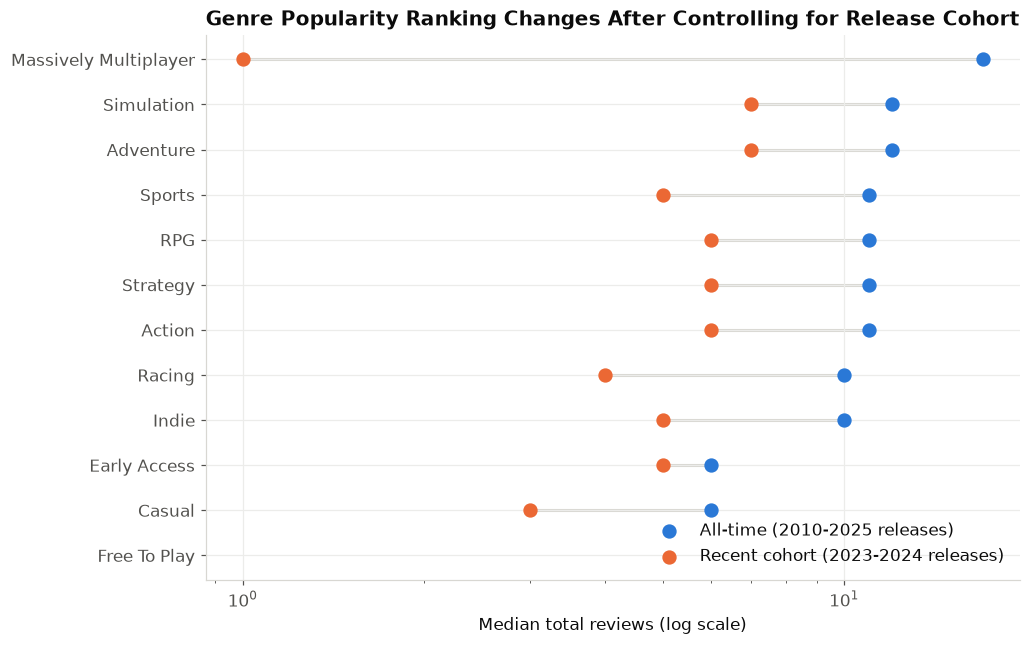

All-time rank (highest median reviews first):
Massively Multiplayer    17.0
Adventure                12.0
Simulation               12.0
Action                   11.0
Strategy                 11.0
RPG                      11.0
Sports                   11.0
Indie                    10.0
Racing                   10.0
Casual                    6.0
Early Access              6.0
Free To Play              0.0
Name: all_time_2010_2025, dtype: float64

Recent-cohort rank:
Adventure                7.0
Simulation               7.0
Action                   6.0
Strategy                 6.0
RPG                      6.0
Early Access             5.0
Indie                    5.0
Sports                   5.0
Racing                   4.0
Casual                   3.0
Massively Multiplayer    1.0
Free To Play             0.0
Name: recent_2023_2024, dtype: float64


In [17]:
recent_cohort = games[(games.release_year >= 2023) & (games.release_year <= 2024)]
alltime_cohort = games[(games.release_year >= 2010) & (games.release_year <= 2025)]

med_alltime = cohort_genre_median(alltime_cohort, TOP_GENRES, 'total_reviews')
med_recent = cohort_genre_median(recent_cohort, TOP_GENRES, 'total_reviews')

cmp = pd.DataFrame({'all_time_2010_2025': med_alltime, 'recent_2023_2024': med_recent}).dropna()
cmp = cmp.sort_values('all_time_2010_2025')

fig, ax = plt.subplots(figsize=(9.5, 6))
y = np.arange(len(cmp))
ax.hlines(y, cmp['recent_2023_2024'], cmp['all_time_2010_2025'], color='#d8d7d2', linewidth=2, zorder=1)
ax.scatter(cmp['all_time_2010_2025'], y, color=BLUE, s=70, zorder=3, label='All-time (2010-2025 releases)')
ax.scatter(cmp['recent_2023_2024'], y, color=ORANGE, s=70, zorder=3, label='Recent cohort (2023-2024 releases)')
ax.set_yticks(y)
ax.set_yticklabels(cmp.index)
ax.set_xscale('log')
ax.set_title('Genre Popularity Ranking Changes After Controlling for Release Cohort')
ax.set_xlabel('Median total reviews (log scale)')
ax.legend(loc='lower right', frameon=False)
fig.tight_layout()
savefig(fig, 'fig10_genre_reception_alltime_vs_recent_cohort.png')
plt.show()

print('All-time rank (highest median reviews first):')
print(cmp['all_time_2010_2025'].sort_values(ascending=False))
print()
print('Recent-cohort rank:')
print(cmp['recent_2023_2024'].sort_values(ascending=False))

**Interpretation — this is where an all-time relationship changes after controlling for release cohort.**
All-time, **Massively Multiplayer** has the *highest* median total_reviews of any major genre (17, vs. 10-12
for most others) — but restricted to the 2023-2024 release cohort, its median collapses to **1**, the
*lowest* of all genres shown, and its cohort sample is small (n=685 recent MMO releases vs. 2,496 all-time).
The all-time ranking is dominated by a handful of long-lived legacy MMO titles that have had a decade or more
to accumulate reviews; recently-released MMOs on Steam are not replicating that success. **Without the
cohort control, "Massively Multiplayer looks like Steam's best-received genre" would be a exposure-time
artifact, not a real current-market pattern.** Early Access also moves up in relative standing once
controlled for cohort (from below Casual all-time to above Casual/Sports/Racing recently) — recent
Early-Access releases pick up review volume comparably to established genres, unlike the legacy MMO pattern.

saved ../figures/phase2/fig11_positive_ratio_by_price_tier.png


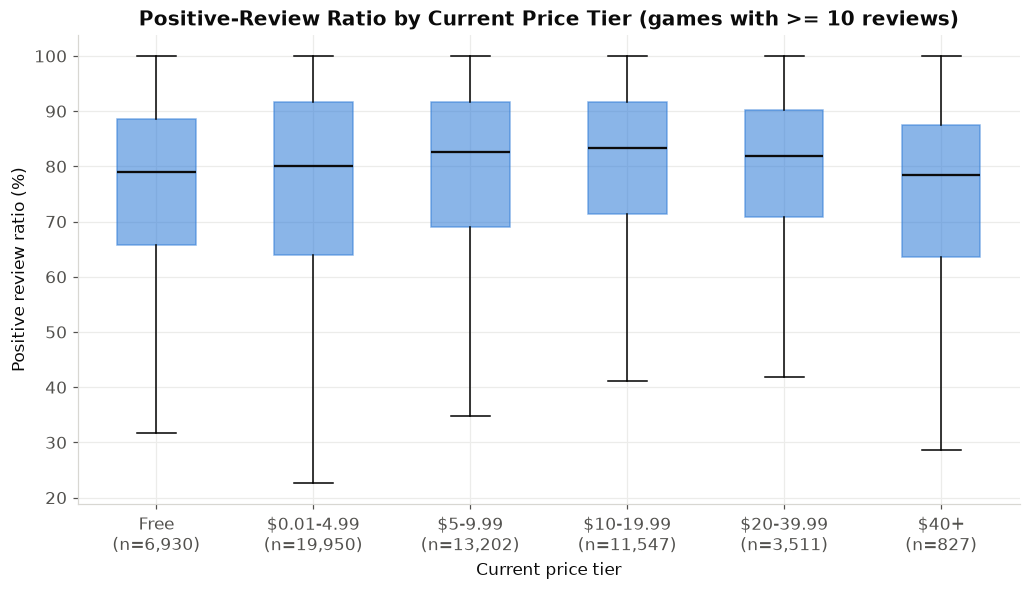

              median      mean  count
price_tier                           
Free        0.789474  0.760783   6930
$0.01-4.99  0.800000  0.757919  19950
$5-9.99     0.825175  0.783034  13202
$10-19.99   0.833333  0.796182  11547
$20-39.99   0.818182  0.786500   3511
$40+        0.784228  0.724748    827


In [18]:
tr_ge10 = games[games['total_reviews'] >= 10].copy()
tr_ge10['price_tier'] = tr_ge10['price_tier'].cat.remove_unused_categories()

fig, ax = plt.subplots(figsize=(9.5, 5.5))
tiers_present = [t for t in PRICE_TIER_LABELS if t in tr_ge10['price_tier'].cat.categories]
data = [tr_ge10.loc[tr_ge10['price_tier'] == t, 'positive_ratio'].dropna() * 100 for t in tiers_present]
ns = [len(d) for d in data]
bp = ax.boxplot(data, tick_labels=[f'{t}\n(n={n:,})' for t, n in zip(tiers_present, ns)],
                 showfliers=False, patch_artist=True, medianprops=dict(color=TEXT_PRIMARY, linewidth=1.5))
for patch in bp['boxes']:
    patch.set_facecolor(BLUE)
    patch.set_alpha(0.55)
    patch.set_edgecolor(BLUE)
ax.set_title('Positive-Review Ratio by Current Price Tier (games with >= 10 reviews)')
ax.set_ylabel('Positive review ratio (%)')
ax.set_xlabel('Current price tier')
fig.tight_layout()
savefig(fig, 'fig11_positive_ratio_by_price_tier.png')
plt.show()

print(tr_ge10.groupby('price_tier', observed=True)['positive_ratio'].agg(['median', 'mean', 'count']))

**Interpretation.** Among games with enough reviews (>=10) for the ratio to be meaningful, median positive
ratio is not monotonic in price — it rises from Free (median 78.9%) through $0.01-4.99 (80.0%), $5-9.99
(82.5%), and peaks at $10-19.99 (83.3%), then declines at $20-39.99 (81.8%) and drops back to 78.4% at $40+,
similar to the Free tier. The effect size is modest throughout (a ~5-point spread between the lowest and
highest median), and every tier is self-selected (only games with enough traction to reach 10+ reviews are
counted at all, and the $40+ tier is a small, unusual group — n=827 — dominated by the novelty/professional-
software listings flagged in the pricing investigation above). This reads as a mild "sweet spot" around
$10-20 rather than a simple "higher price -> better reception" relationship, and should not be read as
evidence that raising price improves reception.

---
# Summary

See `outputs/phase2_market_findings.md` for the recruiter-readable writeup of these findings. In brief:

1. **Evolution**: catalog growth is not broad-based — free-to-play and Early Access release volume grew far
   faster than the catalog overall, while Action/Strategy's *share* of releases declined even as absolute
   counts grew. 2026 is a partial year and is never compared to complete years without that caveat.
2. **Crowding/concentration**: genre landscape is dominated by Indie/Casual/Action/Adventure prevalence, with
   Free To Play and Early Access the fastest-growing recent segments. Developer/publisher supply is
   extremely fragmented (~77% one-off producers, top-10 developer share ~1.1% of catalog) — a release-count
   finding, not a revenue-concentration one.
3. **Pricing**: current prices cluster tightly around recognizable Steam price points (median paid $5.99);
   the extreme-price tail is explainable (novelty/shock listings and professional creative software), not
   data errors. Price is current, not launch, price throughout.
4. **Reception**: total_reviews and a review-count-gated positive_ratio are the two reliable outcome metrics.
   The clearest finding is a genuine cohort-confound reversal — Massively Multiplayer looks like the best-
   received genre all-time, purely because of a few long-lived legacy titles, but the most recently-released
   MMOs on Steam have the *weakest* review traction of any major genre.

This notebook is descriptive only: no predictive model, no success-label definition, no NLP/embeddings/
clustering/recommendation work was performed, per Phase 2 scope.